<a href="https://colab.research.google.com/github/conchoe/gpt2-ioi-circuits-/blob/main/MechInterp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformer_lens
!pip install circuitsvis

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.2 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=9ad01f6d4e5dc9b3a7f903beaba1cf01514e3130acb78d1940a4ed76bf7b17fa
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.8 MB/s eta 0:00:00


In [2]:
import torch
from transformer_lens import HookedTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained("gpt2", device=device)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer


In [13]:
text = "The quick brown fox jumps over the lazy"
logits = model(text)
print(logits.shape)
next_token_logits = logits[0, -1]
predicted_token_id = next_token_logits.argmax()
predicted_word = model.to_string(predicted_token_id)
print(f"After '{text}', the model predicts: '{predicted_word}'")

torch.Size([1, 9, 50257])
After 'The quick brown fox jumps over the lazy', the model predicts: ','


torch.Size([1, 15, 15])


Model predicts: ' Mary'


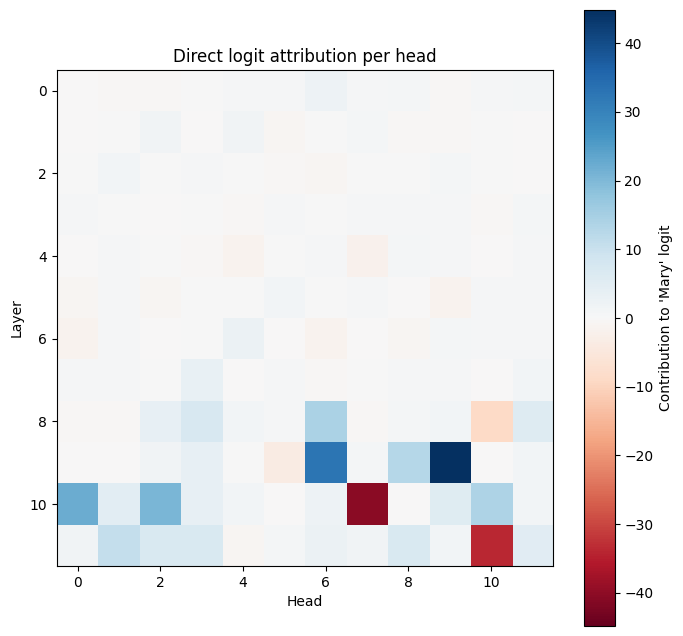

In [14]:
import circuitsvis as cv
from IPython.display import display

text = "When John and Mary went to the store, John gave a drink to"
tokens = model.to_tokens(text)
logits, cache = model.run_with_cache(tokens)
layer = 1
head = 1

attention_pattern = cache["pattern", layer][0, head].unsqueeze(0)
print(attention_pattern.shape)
str_tokens = model.to_str_tokens(text)
vis = (cv.attention.attention_patterns(tokens=str_tokens, attention=attention_pattern))
display(vis) #heatmap
final_logits = logits[0, -1]
top_prediction = model.to_string(final_logits.argmax())
print(f"Model predicts: '{top_prediction}'")

#visualizing how layer and head influences model's prediction
answer_token = model.to_single_token(" Mary")
answer_residual_directions = model.tokens_to_residual_directions(answer_token)

per_head_contributions = cache.stack_head_results(layer=-1)
# shape: [n_layers * n_heads, batch, seq, d_model]

logit_attribution = (per_head_contributions[:, 0, -1, :] @ answer_residual_directions).detach().cpu()

import matplotlib.pyplot as plt
#dark blue = head pushing for mary
#dark red = head pushing against mary

n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
logit_attribution_grid = logit_attribution.reshape(n_layers, n_heads)

plt.figure(figsize=(8,8))
plt.imshow(logit_attribution_grid, cmap="RdBu", vmin=-abs(logit_attribution_grid).max(), vmax=abs(logit_attribution_grid).max())
plt.colorbar(label="Contribution to 'Mary' logit")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Direct logit attribution per head")
plt.show()

In [15]:
def zero_ablate_head(value, hook, head_to_ablate):
    value[:, :, head_to_ablate, :] = 0
    return value

layer_to_test = 10
head_to_test = 7

original_logit = final_logits[answer_token].item()

ablated_logits = model.run_with_hooks(
    tokens,
    fwd_hooks=[(
        f"blocks.{layer_to_test}.attn.hook_z",
        lambda value, hook: zero_ablate_head(value, hook, head_to_test)
    )]
)

ablated_logit = ablated_logits[0, -1, answer_token].item()

print(f"Original 'Mary' logit: {original_logit:.2f}")
print(f"Logit after ablating {layer_to_test}.{head_to_test}: {ablated_logit:.2f}")
print(f"Change: {ablated_logit - original_logit:.2f}")

Original 'Mary' logit: 17.79
Logit after ablating 10.7: 18.85
Change: 1.06


In [16]:
def mean_ablate_head(value, hook, head_to_ablate, mean_value):
    value[:, :, head_to_ablate, :] = mean_value
    return value

mean_activation = cache["z", layer_to_test][:, :, head_to_test, :].mean(dim=(0,1))

ablated_logits_mean = model.run_with_hooks(
    tokens,
    fwd_hooks=[(
        f"blocks.{layer_to_test}.attn.hook_z",
        lambda value, hook: mean_ablate_head(value, hook, head_to_test, mean_activation)
    )]
)

ablated_logit_mean = ablated_logits_mean[0, -1, answer_token].item()
print(f"Original: {original_logit:.2f}, Mean-ablated: {ablated_logit_mean:.2f}, Change: {ablated_logit_mean - original_logit:.2f}")

Original: 17.79, Mean-ablated: 19.02, Change: 1.23


In [17]:
#ablation on Blue Values (Most positive for Mary)
flat_attribution = logit_attribution_grid.flatten()
top_k = 5
top_indices = flat_attribution.argsort(descending=True)[:top_k]

for idx in top_indices:
    l = idx.item() // n_heads
    h = idx.item() % n_heads
    print(f"Layer {l}, Head {h}: {flat_attribution[idx].item():.2f}")

heads_to_ablate = [(9, 9), (9, 6), (10, 0), (10, 2),(8, 6)]  # replace with your actual top 2 from above

def zero_ablate_multiple(value, hook, heads):
    for layer_idx, head_idx in heads:
        if hook.layer() == layer_idx:
            value[:, :, head_idx, :] = 0
    return value

hooks = []
for layer_idx, head_idx in heads_to_ablate:
    hook_name = f"blocks.{layer_idx}.attn.hook_z"
    hooks.append((hook_name, lambda value, hook, heads=heads_to_ablate: zero_ablate_multiple(value, hook, heads)))

ablated_logits_multi = model.run_with_hooks(tokens, fwd_hooks=hooks)
ablated_logit_multi = ablated_logits_multi[0, -1, answer_token].item()

print(f"Original: {original_logit:.2f}")
print(f"Multi-head ablated: {ablated_logit_multi:.2f}")
print(f"Change: {ablated_logit_multi - original_logit:.2f}")

ablated_final_logits = ablated_logits_multi[0, -1]
ablated_prediction = model.to_string(ablated_final_logits.argmax())

print(f"Original prediction: '{model.to_string(final_logits.argmax())}'")
print(f"After ablating top heads: '{ablated_prediction}'")

Layer 9, Head 9: 44.82
Layer 9, Head 6: 32.73
Layer 10, Head 0: 22.40
Layer 10, Head 2: 20.32
Layer 8, Head 6: 14.03
Original: 17.79
Multi-head ablated: 14.91
Change: -2.88
Original prediction: ' Mary'
After ablating top heads: ' them'


In [18]:
#Ablation on Red Values: most negative for Mary
flat_attribution = logit_attribution_grid.flatten()
top_k = 5
top_indices = flat_attribution.argsort(descending=False)[:top_k]

for idx in top_indices:
    l = idx.item() // n_heads
    h = idx.item() % n_heads
    print(f"Layer {l}, Head {h}: {flat_attribution[idx].item():.2f}")

heads_to_ablate = [(10, 7), (11, 10), (8, 10), (9, 5),(4, 7)]  # replace with your actual top 2 from above

def zero_ablate_multiple(value, hook, heads):
    for layer_idx, head_idx in heads:
        if hook.layer() == layer_idx:
            value[:, :, head_idx, :] = 0
    return value

hooks = []
for layer_idx, head_idx in heads_to_ablate:
    hook_name = f"blocks.{layer_idx}.attn.hook_z"
    hooks.append((hook_name, lambda value, hook, heads=heads_to_ablate: zero_ablate_multiple(value, hook, heads)))

ablated_logits_multi = model.run_with_hooks(tokens, fwd_hooks=hooks)
ablated_logit_multi = ablated_logits_multi[0, -1, answer_token].item()

print(f"Original: {original_logit:.2f}")
print(f"Multi-head ablated: {ablated_logit_multi:.2f}")
print(f"Change: {ablated_logit_multi - original_logit:.2f}")

ablated_final_logits = ablated_logits_multi[0, -1]
ablated_prediction = model.to_string(ablated_final_logits.argmax())

print(f"Original prediction: '{model.to_string(final_logits.argmax())}'")
print(f"After ablating top heads: '{ablated_prediction}'")

Layer 10, Head 7: -40.51
Layer 11, Head 10: -33.78
Layer 8, Head 10: -8.85
Layer 9, Head 5: -3.52
Layer 4, Head 7: -2.01
Original: 17.79
Multi-head ablated: 21.05
Change: 3.26
Original prediction: ' Mary'
After ablating top heads: ' Mary'


In [19]:
## DLA on multiple sentences, see if layer 9 head 9 shows up for different variations of the same sentence
def analyze_ioi_sentence(model, sentence, answer_word, top_k=5):
    """
    Runs a sentence through the model, computes DLA for every head
    w.r.t. a specific answer word, and returns the results.
    """
    tokens = model.to_tokens(sentence)
    logits, cache = model.run_with_cache(tokens)

    answer_token = model.to_single_token(answer_word)
    answer_residual_direction = model.tokens_to_residual_directions(answer_token)

    per_head_contributions = cache.stack_head_results(layer=-1)
    logit_attribution = (per_head_contributions[:, 0, -1, :] @ answer_residual_direction).detach().cpu()

    n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
    grid = logit_attribution.reshape(n_layers, n_heads)

    flat = grid.flatten()
    top_indices = flat.argsort(descending=True)[:top_k]
    bottom_indices = flat.argsort(descending=False)[:top_k]

    top_heads = [(idx.item() // n_heads, idx.item() % n_heads, flat[idx].item()) for idx in top_indices]
    bottom_heads = [(idx.item() // n_heads, idx.item() % n_heads, flat[idx].item()) for idx in bottom_indices]

    predicted_word = model.to_string(logits[0, -1].argmax())

    return {
        "sentence": sentence,
        "predicted_word": predicted_word,
        "grid": grid,
        "top_heads": top_heads,
        "bottom_heads": bottom_heads,
        "logits": logits,
        "cache": cache,
    }

test_cases = [
    ("When John and Mary went to the store, John gave a drink to", " Mary"),
    ("When Tom and Sarah went to the park, Tom gave the ball to", " Sarah"),
    ("After Alice and Bob left the office, Alice handed the keys to", " Bob"),
    ("When Sam and Lily arrived at the party, Sam passed the cake to", " Lily"),
    ("Once she and him got there, he passed his keys to", " her"),
    ("When X and Y got there, X gave their thing to", " Y"),
    ("After Ryan and Nolan arrived at the field, Nolan handed his glove to", " Ryan"),
    ("After Jack and Jill parked their car, Jill passed her bags to", " Jack"),
    ("When he and her went to the store, he gave a drink to", " her"),
    ("Once Alex and Quinn got there, Alex passed his keys to", " Quinn")
]

results = []
for sentence, answer in test_cases:
    result = analyze_ioi_sentence(model, sentence, answer)
    results.append(result)
    print(f"'{sentence[:40]}...' -> predicted '{result['predicted_word']}' (target: '{answer}')")
    print(f"  Top head: layer {result['top_heads'][0][0]}, head {result['top_heads'][0][1]} ({result['top_heads'][0][2]:.2f})")

from collections import Counter

top_head_counter = Counter()
for r in results:
    for layer, head, score in r["top_heads"]:
        top_head_counter[(layer, head)] += 1

print("Heads appearing in top-5 across sentences:")
for (layer, head), count in top_head_counter.most_common(10):
    print(f"  Layer {layer}, Head {head}: appeared in {count}/{len(results)} sentences")

'When John and Mary went to the store, Jo...' -> predicted ' Mary' (target: ' Mary')
  Top head: layer 9, head 9 (44.82)
'When Tom and Sarah went to the park, Tom...' -> predicted ' Sarah' (target: ' Sarah')
  Top head: layer 9, head 9 (65.80)
'After Alice and Bob left the office, Ali...' -> predicted ' Bob' (target: ' Bob')
  Top head: layer 9, head 9 (41.64)
'When Sam and Lily arrived at the party, ...' -> predicted ' Lily' (target: ' Lily')
  Top head: layer 9, head 9 (67.90)
'Once she and him got there, he passed hi...' -> predicted ' her' (target: ' her')
  Top head: layer 11, head 8 (18.98)
'When X and Y got there, X gave their thi...' -> predicted ' Y' (target: ' Y')
  Top head: layer 9, head 9 (32.65)
'After Ryan and Nolan arrived at the fiel...' -> predicted ' Ryan' (target: ' Ryan')
  Top head: layer 9, head 9 (56.79)
'After Jack and Jill parked their car, Ji...' -> predicted ' Jack' (target: ' Jack')
  Top head: layer 9, head 9 (49.35)
'When he and her went to the store, he 

In [20]:
## See if layer 11 head 8 is responsible for pronoun attribution and
## Layer 9 head 9 is responsible for name retrieval
# Hypothesized from previous result




name_sentences = [
    ("When John and Mary went to the store, John gave a drink to", " Mary"),
    ("When Tom and Sarah went to the park, Tom gave the ball to", " Sarah"),
    ("After Alice and Bob left the office, Alice handed the keys to", " Bob"),
    ("When Sam and Lily arrived at the party, Sam passed the cake to", " Lily"),
    ("Once Josh and Parker arrived in the office, Parker gave his coat to", " Josh"),
    ("After Jack and Jill parked their car, Jill passed her bags to", " Jack"),
    ("Once Alex and Quinn got there, Alex passed his keys to", " Quinn")
    # ... your other name-based ones
]

pronoun_sentences = [
    ("Once she and him got there, he passed his thing to", " her"),
    ("When he and her went to the store, he gave it to", " her"),
    ("After he and her left the office, she handed the keys to", " him"),
    ("When he and her arrived at the party, he passed the cake to", " her"),
    ("Once they arrived in the office, he gave his coat to", "him"),
    ("After they left the office, she handed the keys to", "him"),
    ("When they arrived at the party, he passed the cake to", "him")
    # add a few more pronoun variants: "him", "her", maybe "them"
]

name_results = [analyze_ioi_sentence(model, s, a) for s, a in name_sentences]
pronoun_results = [analyze_ioi_sentence(model, s, a) for s, a in pronoun_sentences]

def top_head_frequency(results):
    counter = Counter()
    for r in results:
        for layer, head, score in r["top_heads"]:
            counter[(layer, head)] += 1
    return counter

print("Name condition:", top_head_frequency(name_results).most_common(5))
print("Pronoun condition:", top_head_frequency(pronoun_results).most_common(5))


def ablate_and_check(model, sentence, answer_word, layer, head):
    tokens = model.to_tokens(sentence)
    answer_token = model.to_single_token(answer_word)
    original_logits = model(tokens)
    original_logit = original_logits[0, -1, answer_token].item()

    def zero_head(value, hook):
        value[:, :, head, :] = 0
        return value

    ablated_logits = model.run_with_hooks(
        tokens, fwd_hooks=[(f"blocks.{layer}.attn.hook_z", zero_head)]
    )
    ablated_logit = ablated_logits[0, -1, answer_token].item()
    return original_logit, ablated_logit, ablated_logit - original_logit



Name condition: [((9, 9), 7), ((9, 6), 7), ((10, 0), 6), ((10, 2), 5), ((10, 10), 4)]
Pronoun condition: [((8, 5), 6), ((11, 8), 5), ((11, 7), 5), ((10, 9), 4), ((8, 3), 3)]


In [21]:
def dla_for_target(model, tokens, cache, target_word, top_k=5):
    target_token = model.to_single_token(target_word)
    target_direction = model.tokens_to_residual_directions(target_token)
    per_head_contributions = cache.stack_head_results(layer=-1)
    attribution = (per_head_contributions[:, 0, -1, :] @ target_direction).detach().cpu()
    n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
    grid = attribution.reshape(n_layers, n_heads)
    flat = grid.flatten()
    top_indices = flat.argsort(descending=True)[:top_k]
    return [(idx.item() // n_heads, idx.item() % n_heads, flat[idx].item()) for idx in top_indices]

text = "When John and Mary went to the store, John gave a drink to"
tokens = model.to_tokens(text)
heads_to_ablate = [(9, 9), (9, 6), (10, 0), (10, 2), (8, 6)]

def zero_ablate_multiple(value, hook, heads):
    for l, h in heads:
        if hook.layer() == l:
            value[:, :, h, :] = 0
    return value

hooks = [(f"blocks.{l}.attn.hook_z", lambda v, hook, heads=heads_to_ablate: zero_ablate_multiple(v, hook, heads))
         for l in set(l for l, h in heads_to_ablate)]

with model.hooks(fwd_hooks=hooks):
    ablated_logits, ablated_cache = model.run_with_cache(tokens)

print("Top heads for 'Them' after ablation:")
print(dla_for_target(model, tokens, ablated_cache, " them"))

print("Top heads for 'Mary' after ablation (should be much weaker now):")
print(dla_for_target(model, tokens, ablated_cache, " Mary"))

Top heads for 'Them' after ablation:


[(11, 8, 14.89488410949707), (8, 3, 12.017879486083984), (10, 9, 11.945588111877441), (8, 5, 5.081379413604736), (7, 3, 3.0336875915527344)]
Top heads for 'Mary' after ablation (should be much weaker now):
[(11, 2, 25.07168197631836), (10, 10, 21.600013732910156), (11, 1, 15.953848838806152), (9, 8, 10.750843048095703), (11, 6, 7.563915252685547)]


# Confirm that the model outputs a pronoun when Name heads are Ablated

In [22]:
def get_top_heads(model, sentence, answer_word, top_k=5):
    """
    Given a sentence and the correct next-word answer, returns the top_k heads
    (by Direct Logit Attribution) that contribute most strongly toward that answer.

    Returns a list of tuples: (layer, head, contribution_score)
    """

    # --- Step 1: tokenize the sentence and run it through the model, caching everything ---
    tokens = model.to_tokens(sentence)
    logits, cache = model.run_with_cache(tokens)

    # --- Step 2: figure out the "direction" in the model's internal space that corresponds
    # to the answer word (this is what DLA measures contribution TOWARD) ---
    answer_token = model.to_single_token(answer_word)
    answer_direction = model.tokens_to_residual_directions(answer_token)

    # --- Step 3: get every individual head's output contribution at the final position ---
    # stack_head_results gives us, for every head in the model, what it individually
    # added to the residual stream (the "notepad") at each position
    per_head_contributions = cache.stack_head_results(layer=-1)

    # --- Step 4: measure how much each head's contribution points toward the answer ---
    # this is a dot product: "how aligned is this head's output with the direction
    # that would increase the answer word's logit?"
    attribution = (per_head_contributions[:, 0, -1, :] @ answer_direction).detach().cpu()

    # --- Step 5: reshape into a (layer x head) grid, so we can identify WHICH head is which ---
    n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
    grid = attribution.reshape(n_layers, n_heads)

    # --- Step 6: find the top_k highest-scoring heads and convert back to (layer, head) pairs ---
    flat = grid.flatten()
    top_indices = flat.argsort(descending=True)[:top_k]

    top_heads = [
        (idx.item() // n_heads, idx.item() % n_heads, flat[idx].item())
        for idx in top_indices
    ]

    return top_heads

In [23]:
tom_sarah_top_heads = get_top_heads(
    model,
    "When Tom and Sarah went to the park, Tom gave the ball to",
    " Sarah"
)
print(tom_sarah_top_heads)

alice_bob_top_heads = get_top_heads(
    model,
    "After Alice and Bob left the office, Alice handed the keys to",
    " Bob"
)
print(alice_bob_top_heads)

sam_lily_top_heads = get_top_heads(
    model,
    "When Sam and Lily arrived at the party, Sam passed the cake to",
    " Lily"
)
print(f"sam and lily top heads: {sam_lily_top_heads}")

josh_and_parker_top_heads = get_top_heads(
    model,
    "Once Josh and Parker arrived in the office, Parker gave his coat to",
    " Josh"
)
print(f"josh and parker top heads: {josh_and_parker_top_heads}")

jack_and_jill_top_heads = get_top_heads(
    model,
    "After Jack and Jill parked their car, Jill passed her bags to",
    " Jack"
)
print(f"jack and jill top heads: {jack_and_jill_top_heads}")

alex_and_quinn_top_heads = get_top_heads(
    model,
    "Once Alex and Quinn got there, Alex passed his keys to",
    " Quinn"
)
print(f"alex and quinn top heads: {alex_and_quinn_top_heads}")


def ablate_and_check_fallback(model, sentence, correct_answer, heads_to_ablate, dla_top_k=5):
    """
    Takes a sentence, ablates a specified group of heads (e.g. name-mover heads),
    and checks what the model predicts instead. Then runs DLA on that NEW predicted
    word to see which heads are driving the fallback behavior.

    This lets us test: "when we remove the name-copying circuit, does the same
    fallback circuit (e.g. pronoun heads) light up every time?"
    """

    # --- Step 1: tokenize the sentence and get the ORIGINAL (unablated) prediction ---
    tokens = model.to_tokens(sentence)
    original_logits = model(tokens)
    original_answer_token = model.to_single_token(correct_answer)
    original_predicted_word = model.to_string(original_logits[0, -1].argmax())

    # --- Step 2: define the ablation hook ---
    # This function gets called during the forward pass, and zeroes out
    # the output of any head in our `heads_to_ablate` list at this layer.
    def zero_ablate_multiple(value, hook, heads):
        for layer_idx, head_idx in heads:
            if hook.layer() == layer_idx:
                value[:, :, head_idx, :] = 0
        return value

    # We need one hook per unique layer that appears in heads_to_ablate
    # (a single hook can zero out multiple heads within that layer)
    unique_layers = set(layer_idx for layer_idx, head_idx in heads_to_ablate)
    hooks = [
        (f"blocks.{layer_idx}.attn.hook_z",
         lambda v, hook, heads=heads_to_ablate: zero_ablate_multiple(v, hook, heads))
        for layer_idx in unique_layers
    ]

    # --- Step 3: run the model WITH the ablation hooks active, and cache activations ---
    # model.hooks(...) temporarily attaches our hooks just for this call,
    # then automatically removes them afterward so they don't affect future runs.
    with model.hooks(fwd_hooks=hooks):
        ablated_logits, ablated_cache = model.run_with_cache(tokens)

    # --- Step 4: see what the model predicts NOW that name movers are gone ---
    ablated_predicted_token = ablated_logits[0, -1].argmax()
    ablated_predicted_word = model.to_string(ablated_predicted_token)

    # --- Step 5: run DLA on the NEW predicted word using the ablated cache ---
    # This tells us: which heads are responsible for THIS fallback prediction?
    fallback_direction = model.tokens_to_residual_directions(ablated_predicted_token)
    per_head_contributions = ablated_cache.stack_head_results(layer=-1)
    fallback_attribution = (per_head_contributions[:, 0, -1, :] @ fallback_direction).detach().cpu()

    n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
    fallback_grid = fallback_attribution.reshape(n_layers, n_heads)
    flat = fallback_grid.flatten()
    top_indices = flat.argsort(descending=True)[:dla_top_k]
    top_fallback_heads = [
        (idx.item() // n_heads, idx.item() % n_heads, flat[idx].item())
        for idx in top_indices
    ]

    # --- Step 6: return everything in one tidy dictionary ---
    return {
        "sentence": sentence,
        "original_prediction": original_predicted_word,
        "ablated_prediction": ablated_predicted_word,   # <- what did it fall back to?
        "top_fallback_heads": top_fallback_heads,        # <- which heads drove that fallback?
        "heads_ablated": heads_to_ablate,
    }


# Each entry: (sentence, correct_answer, [name-mover heads specific to that sentence])
# Use each sentence's own top-5 heads from your earlier per-sentence DLA runs.

test_configs = [
    ("When Tom and Sarah went to the park, Tom gave the ball to", " Sarah",
     [(9,9), (9,6), (10,0), (8,6), (10,2)]),  # replace with Tom/Sarah's actual top-5
    ("After Alice and Bob left the office, Alice handed the keys to", " Bob",
     [(9,9), (9,6), (10,0), (10,10), (10,2)]),  # replace with Alice/Bob's actual top-5
    ("When Sam and Lily arrived at the party, Sam passed the cake to", " Lily",
     [(9, 9), (9, 6), (10, 0), (9, 8), (10, 10)]),  # replace with Sam/Lily's actual top-5
    ("Once Josh and Parker arrived in the office, Parker gave his coat to", " Josh",
     [(9, 9), (10, 2), (9, 6), (10, 0), (11, 9)]),
    ("After Jack and Jill parked their car, Jill passed her bags to", " Jack",
     [(9, 9), (9, 6), (10, 2), (11, 1), (10, 10)]),
    ("Once Alex and Quinn got there, Alex passed his keys to", " Quinn",
     [(9, 6), (9, 9), (10, 0), (10, 10), (10, 6)])

]

for sentence, answer, heads in test_configs:
    result = ablate_and_check_fallback(model, sentence, answer, heads)
    print(f"Sentence: {result['sentence'][:50]}...")
    print(f"  Original prediction: '{result['original_prediction']}'")
    print(f"  After ablation: '{result['ablated_prediction']}'")
    print(f"  Top heads for fallback word: {result['top_fallback_heads']}")
    print()

[(9, 9, 65.7978515625), (9, 6, 33.19380187988281), (10, 0, 29.71401023864746), (8, 6, 16.701309204101562), (10, 2, 15.252732276916504)]
[(9, 9, 41.63986587524414), (9, 6, 23.883625030517578), (10, 0, 20.21196937561035), (10, 10, 18.491004943847656), (10, 2, 16.679100036621094)]
sam and lily top heads: [(9, 9, 67.89675903320312), (9, 6, 44.34220886230469), (10, 0, 25.243419647216797), (9, 8, 16.97842788696289), (10, 10, 13.31550407409668)]
josh and parker top heads: [(9, 9, 61.52250671386719), (10, 2, 20.052532196044922), (9, 6, 19.07265853881836), (10, 0, 16.951358795166016), (11, 9, 12.064240455627441)]
jack and jill top heads: [(9, 9, 49.34657669067383), (9, 6, 28.943233489990234), (10, 2, 25.382919311523438), (11, 1, 22.59621810913086), (10, 10, 22.256427764892578)]
alex and quinn top heads: [(9, 6, 58.970611572265625), (9, 9, 58.4863395690918), (10, 0, 37.41734313964844), (10, 10, 23.63385772705078), (10, 6, 21.99692153930664)]
Sentence: When Tom and Sarah went to the park, Tom gav

# Attention Pattern Visualization on 11, 8

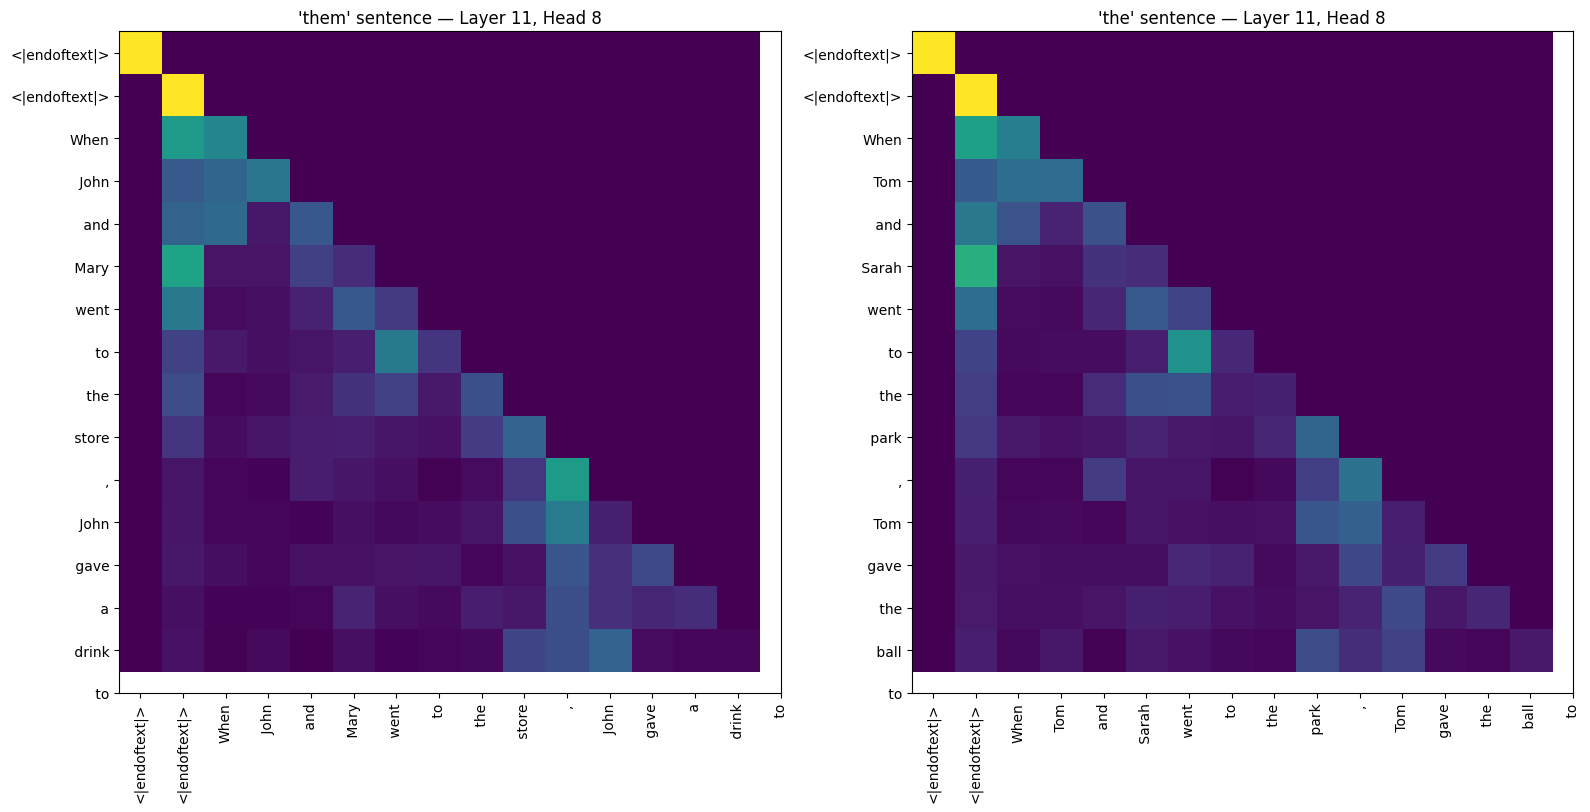

In [24]:
# --- Step 1: rerun the ablation manually so we keep access to the cache ---
# (same logic as inside ablate_and_check_fallback, just exposing the cache this time)

def get_ablated_cache(model, sentence, heads_to_ablate):
    tokens = model.to_tokens(sentence)

    def zero_ablate_multiple(value, hook, heads):
        for layer_idx, head_idx in heads:
            if hook.layer() == layer_idx:
                value[:, :, head_idx, :] = 0
        return value

    unique_layers = set(layer_idx for layer_idx, head_idx in heads_to_ablate)
    hooks = [
        (f"blocks.{layer_idx}.attn.hook_z",
         lambda v, hook, heads=heads_to_ablate: zero_ablate_multiple(v, hook, heads))
        for layer_idx in unique_layers
    ]

    with model.hooks(fwd_hooks=hooks):
        logits, cache = model.run_with_cache(tokens)

    return logits, cache, tokens

# --- Step 2: run it for BOTH sentences, using each sentence's own name-mover heads ---

# "them" sentence
them_sentence = "When John and Mary went to the store, John gave a drink to"
them_heads_to_ablate = [(9,9), (9,6), (10,0), (10,2), (8,6)]  # John/Mary's top-5
them_logits, them_cache, them_tokens = get_ablated_cache(model, them_sentence, them_heads_to_ablate)

# "the" sentence
the_sentence = "When Tom and Sarah went to the park, Tom gave the ball to"
the_heads_to_ablate = [(9, 9), (9, 6), (10, 0), (8, 6), (10, 2)]  # Tom/Sarah's actual top-5 — fill in from your get_top_heads call
the_logits, the_cache, the_tokens = get_ablated_cache(model, the_sentence, the_heads_to_ablate)


# --- Step 3: visualize (11, 8)'s attention pattern for both, side by side ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, cache, tokens, title in [
    (axes[0], them_cache, them_tokens, "'them' sentence — Layer 11, Head 8"),
    (axes[1], the_cache, the_tokens, "'the' sentence — Layer 11, Head 8"),
]:
    attention_pattern = cache["pattern", 11][0, 8]  # layer 11, head 8
    str_tokens = model.to_str_tokens(model.to_string(tokens[0]))

    im = ax.imshow(attention_pattern.detach().cpu().numpy(), cmap="viridis")
    ax.set_xticks(range(len(str_tokens)))
    ax.set_yticks(range(len(str_tokens)))
    ax.set_xticklabels(str_tokens, rotation=90)
    ax.set_yticklabels(str_tokens)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [25]:
# Get just the final row (the "to" position) for both sentences
them_final_row = them_cache["pattern", 11][0, 8][-1]  # last query position
the_final_row = the_cache["pattern", 11][0, 8][-1]

them_str_tokens = model.to_str_tokens(model.to_string(them_tokens[0]))
the_str_tokens = model.to_str_tokens(model.to_string(the_tokens[0]))

print("'them' sentence — attention from final position:")
for tok, weight in zip(them_str_tokens, them_final_row.tolist()):
    print(f"  {tok!r}: {weight:.3f}")

print("\n'the' sentence — attention from final position:")
for tok, weight in zip(the_str_tokens, the_final_row.tolist()):
    print(f"  {tok!r}: {weight:.3f}")

'them' sentence — attention from final position:
  '<|endoftext|>': 0.000
  '<|endoftext|>': 0.049
  'When': 0.007
  ' John': 0.026
  ' and': 0.003
  ' Mary': 0.041
  ' went': 0.011
  ' to': 0.015
  ' the': 0.023
  ' store': 0.211
  ',': 0.242
  ' John': 0.314
  ' gave': 0.031
  ' a': 0.013
  ' drink': 0.015

'the' sentence — attention from final position:
  '<|endoftext|>': 0.000
  '<|endoftext|>': 0.084
  'When': 0.023
  ' Tom': 0.064
  ' and': 0.008
  ' Sarah': 0.070
  ' went': 0.049
  ' to': 0.023
  ' the': 0.015
  ' park': 0.229
  ',': 0.129
  ' Tom': 0.198
  ' gave': 0.027
  ' the': 0.013
  ' ball': 0.068


In [26]:
def get_final_row_attention(cache, tokens, layer=11, head=8):
    """Extract attention weights from the final token position, paired with their words."""
    final_row = cache["pattern", layer][0, head][-1]
    str_tokens = model.to_str_tokens(model.to_string(tokens[0]))
    return list(zip(str_tokens, final_row.tolist()))

# Run across more sentences and look for the same 3-part pattern:
# (1) repeated subject name, (2) location/object noun, (3) comma/clause boundary

# Testing 11, 2 as a backup circuit


In [27]:
sam_lily_top10 = get_top_heads(model, "When Sam and Lily arrived at the party, Sam passed the cake to", " Lily", top_k=10)
print(f"sam and lily top 10: {sam_lily_top10}")

alex_quinn_top10 = get_top_heads(model, "Once Alex and Quinn got there, Alex passed his keys to", " Quinn", top_k = 10)
print(f"alex and quinn top 10: {alex_quinn_top10}")

sam and lily top 10: [(9, 9, 67.89675903320312), (9, 6, 44.34220886230469), (10, 0, 25.243419647216797), (9, 8, 16.97842788696289), (10, 10, 13.31550407409668), (8, 6, 12.398633003234863), (10, 2, 10.661006927490234), (8, 11, 10.285154342651367), (11, 2, 10.12381649017334), (11, 3, 10.014355659484863)]
alex and quinn top 10: [(9, 6, 58.970611572265625), (9, 9, 58.4863395690918), (10, 0, 37.41734313964844), (10, 10, 23.63385772705078), (10, 6, 21.99692153930664), (9, 8, 16.128257751464844), (10, 2, 14.552626609802246), (11, 3, 7.093178749084473), (10, 1, 6.20622444152832), (8, 11, 5.769188404083252)]


In [28]:
# --- Step 1: define the two test cases we're checking ---
# Each needs: the sentence, and its own top-5 heads to ablate (from your DLA results)

backup_test_cases = [
    {
        "sentence": "When Sam and Lily arrived at the party, Sam passed the cake to",
        "answer": " Lily",
        "heads_to_ablate": [(9,9), (9,6), (10,0), (9,8), (10,10)],  # Sam/Lily's actual top-5
    },
    {
        "sentence": "Once Alex and Quinn got there, Alex passed his key to",
        "answer": " Quinn",
        "heads_to_ablate": [(9,6), (9,9), (10,0), (10,10), (10,6)],  # Alex/Quinn's actual top-5
    },
]

# --- Step 2: for each sentence, get BOTH the original and ablated attention pattern for (11,2) ---

for case in backup_test_cases:
    sentence = case["sentence"]
    tokens = model.to_tokens(sentence)
    str_tokens = model.to_str_tokens(sentence)

    # Original (unablated) run — just a normal cached forward pass
    _, original_cache = model.run_with_cache(tokens)

    # Ablated run — reuse your existing get_ablated_cache helper
    _, ablated_cache, _ = get_ablated_cache(model, sentence, case["heads_to_ablate"])

    # Pull (11,2)'s attention from the FINAL position (the one making the prediction)
    original_pattern = original_cache["pattern", 11][0, 2][-1]
    ablated_pattern = ablated_cache["pattern", 11][0, 2][-1]

    print(f"=== {sentence} ===")
    print(f"{'Token':<12} {'Original':>10} {'Ablated':>10}")
    for tok, orig_w, abl_w in zip(str_tokens, original_pattern.tolist(), ablated_pattern.tolist()):
        print(f"{tok:<12} {orig_w:>10.3f} {abl_w:>10.3f}")
    print()

=== When Sam and Lily arrived at the party, Sam passed the cake to ===
Token          Original    Ablated
<|endoftext|>      0.672      0.231
When              0.013      0.011
 Sam              0.071      0.082
 and              0.029      0.028
 Lily             0.118      0.560
 arrived          0.003      0.003
 at               0.010      0.007
 the              0.005      0.003
 party            0.003      0.002
,                 0.015      0.012
 Sam              0.024      0.026
 passed           0.005      0.002
 the              0.003      0.003
 cake             0.006      0.015
 to               0.022      0.015

=== Once Alex and Quinn got there, Alex passed his key to ===
Token          Original    Ablated
<|endoftext|>      0.715      0.261
Once              0.007      0.004
 Alex             0.061      0.116
 and              0.042      0.030
 Quinn            0.076      0.494
 got              0.002      0.002
 there            0.010      0.005
,                 0.028 

Notice how the weight on Quinn and Lily increase significantly from the original to the ablated run. This shows that this 11, 2 head is not getting outvoted, but it is activated as a "backup name mover" just as described in Wang et al. (2022). Before ablation, (11,2) was mostly parked on the attention sink, essentially doing very little task-relevant work, but and once the primary name movers are removed, it redirects a large chunk of that attention specifically onto the correct name.

# Predicting outcomes

In [29]:
import pandas as pd

# --- Step 1: a function to generate lots of sentences from templates ---
# This lets you cheaply create hundreds of variations by mixing names, verbs, and objects,
# instead of hand-typing every sentence.

def generate_ioi_sentences(name_pairs, verbs, objects, templates=None):
    """
    name_pairs: list of (name1, name2) tuples, e.g. [("John", "Mary"), ("Tom", "Sarah")]
    verbs: list of verbs, e.g. ["gave", "handed", "passed"]
    objects: list of objects, e.g. ["the ball", "the keys", "a drink"]
    templates: optional list of sentence templates with {name1}, {name2}, {verb}, {object} placeholders

    Returns a list of dicts, each with the sentence, the correct answer, and its component parts
    (so you can group/filter by verb, object, etc. later).
    """
    if templates is None:
        templates = [
            "When {name1} and {name2} went to the store, {name1} {verb} {object} to",
        ]

    sentences = []
    for name1, name2 in name_pairs:
        for verb in verbs:
            for obj in objects:
                for template in templates:
                    sentence = template.format(name1=name1, name2=name2, verb=verb, object=obj)
                    sentences.append({
                        "sentence": sentence,
                        "answer": f" {name2}",  # the correct indirect object
                        "name1": name1,
                        "name2": name2,
                        "verb": verb,
                        "object": obj,
                    })
    return sentences

In [30]:
# --- Step 2: the per-sentence pipeline, wrapped to return a flat dict (easy to turn into a DataFrame row) ---

def run_full_pipeline(model, sentence_info, top_k=5):
    """
    Takes one sentence_info dict (from generate_ioi_sentences), runs the full
    analysis (top heads -> ablate -> check fallback), and returns a single flat
    dict summarizing everything -- ready to become one row in a DataFrame.
    """
    sentence = sentence_info["sentence"]
    answer = sentence_info["answer"]

    # Find this sentence's own top-5 name-mover heads
    top_heads = get_top_heads(model, sentence, answer, top_k=top_k)
    heads_to_ablate = [(l, h) for l, h, score in top_heads]

    # Ablate them and see what happens
    result = ablate_and_check_fallback(model, sentence, answer, heads_to_ablate, dla_top_k=top_k)

    # Categorize the outcome into a simple label -- this is the key column for pattern-finding later
    ablated_pred = result["ablated_prediction"].strip().lower()
    correct_name = answer.strip().lower()

    if ablated_pred == correct_name:
        outcome = "backup_rescue"
    elif ablated_pred in ["the", "a", "his", "her", "their"]:
        outcome = "determiner_or_possessive_fallback"
    elif ablated_pred in ["him", "her", "them"]:
        outcome = "pronoun_fallback"
    else:
        outcome = "other"

    # Flatten everything into one dict -- one row of your eventual DataFrame
    return {
        **sentence_info,                     # sentence, name1, name2, verb, object
        "original_prediction": result["original_prediction"],
        "ablated_prediction": result["ablated_prediction"],
        "outcome": outcome,
        "top_head_1": top_heads[0][:2],       # (layer, head) of the single strongest name-mover
        "top_fallback_head_1": result["top_fallback_heads"][0][:2],  # strongest head driving the fallback
    }

In [31]:
# --- Step 3: run it across everything and collect into a DataFrame ---

def run_batch(model, sentence_infos):
    """
    Runs run_full_pipeline over a whole list of sentence_infos and returns
    a pandas DataFrame -- one row per sentence, ready for groupby/filtering.
    """
    rows = []
    for i, sentence_info in enumerate(sentence_infos):
        try:
            row = run_full_pipeline(model, sentence_info)
            rows.append(row)
        except Exception as e:
            # Don't let one bad sentence (e.g. tokenization edge case) kill the whole batch
            print(f"Skipped sentence {i} ({sentence_info['sentence'][:30]}...): {e}")

        if (i + 1) % 20 == 0:
            print(f"Processed {i+1}/{len(sentence_infos)} sentences...")

    return pd.DataFrame(rows)

In [32]:
name_pairs = [("Tom", "Sarah"), ("Alice", "Bob"), ("Sam", "Lily"), ("Alex", "Quinn"),
              ("Jack", "Jill"), ("Ryan", "Nolan"), ("John", "Mary"), ("Connor", "Zach"),
              ("Jason", "Sharon"), ("Fred", "Ned")]  # add more freely
verbs = ["gave", "handed", "passed", "brought", "tossed"]
objects = ["the ball", "the keys", "the drink", "the cake", "the letter"]

sentence_infos = generate_ioi_sentences(name_pairs, verbs, objects)
print(f"Generated {len(sentence_infos)} sentences")  # 7 x 5 x 5 = 175

df = run_batch(model, sentence_infos)
df.to_csv("ioi_fallback_results.csv", index=False)  # save so you don't lose hours of compute

Generated 250 sentences
Processed 20/250 sentences...
Processed 40/250 sentences...
Processed 60/250 sentences...
Processed 80/250 sentences...
Processed 100/250 sentences...
Processed 120/250 sentences...
Processed 140/250 sentences...
Processed 160/250 sentences...
Processed 180/250 sentences...
Processed 200/250 sentences...
Processed 220/250 sentences...
Processed 240/250 sentences...


In [33]:
# Does verb predict outcome?
print(df.groupby("verb")["outcome"].value_counts())

# Does object predict outcome?
print(df.groupby("object")["outcome"].value_counts())

# Cross-tab: verb x object x outcome, to spot interaction effects
print(pd.crosstab(df["verb"], df["outcome"]))

# Which fallback heads show up most often, and for which outcome type?
print(df.groupby("outcome")["top_fallback_head_1"].value_counts())

#Note: determiner_or_possesive_fallback is "the", "a", or unrelated pronoun
        # pronoun_fallback is a pronoun that could fill in for the name
        #backup_rescue is when the model predicts the original outcome even after ablation

verb     outcome                          
brought  determiner_or_possessive_fallback    34
         pronoun_fallback                     13
         backup_rescue                         3
gave     backup_rescue                        36
         determiner_or_possessive_fallback    12
         pronoun_fallback                      2
handed   backup_rescue                        39
         determiner_or_possessive_fallback     8
         pronoun_fallback                      3
passed   backup_rescue                        31
         determiner_or_possessive_fallback    17
         pronoun_fallback                      2
tossed   determiner_or_possessive_fallback    36
         backup_rescue                        14
Name: count, dtype: int64
object      outcome                          
the ball    backup_rescue                        27
            determiner_or_possessive_fallback    21
            pronoun_fallback                      2
the cake    backup_rescue                  

In [34]:
##Check plural objects. "the keys" had mostly determiner or possesive fallback,
## while tanking the backup rescue prediction.
##check to see if this is because it was the only plural object



# --- Step 1: build a plural object set that mirrors your existing singular set ---
# Same nouns, same definite article convention -- only pluralized.
# This isolates grammatical number as the ONE variable that changes.

plural_objects = ["the balls", "the cakes", "the letters", "the drinks", "the keys"]
# note: "the keys" is already plural in your existing data -- keep it in both
# sets as a built-in sanity check (it should land in roughly the same place)

singular_objects = ["the ball", "the cake", "the letter", "the drink", "the key"]  # for reference/re-use

# --- Step 2: generate sentences using your EXISTING name_pairs and verbs ---
# Re-use the exact same name_pairs and verbs list you already used, so the only
# thing that's different between this batch and your existing df is the object's number.

name_pairs = [("Tom","Sarah"), ("Alice","Bob"), ("Sam","Lily"), ("Alex","Quinn"),
              ("Jack","Jill"), ("Ryan","Nolan"), ("John","Mary"), ("Connor","Zach"),
              ("Jason","Sharon"), ("Fred","Ned")]  # fill in name2 for Connor/Jason/Fred from your original list

verbs = ["gave", "handed", "passed", "brought", "tossed"]

plural_sentence_infos = generate_ioi_sentences(name_pairs, verbs, plural_objects)
print(f"Generated {len(plural_sentence_infos)} plural sentences")  # 10 x 5 x 5 = 250

# --- Step 3: run the batch (this will take a few minutes, same as before) ---
plural_df = run_batch(model, plural_sentence_infos)
plural_df["grammatical_number"] = "plural"

plural_df.to_csv("ioi_plural_results.csv", index=False)

Generated 250 plural sentences
Processed 20/250 sentences...
Processed 40/250 sentences...
Processed 60/250 sentences...
Processed 80/250 sentences...
Processed 100/250 sentences...
Processed 120/250 sentences...
Processed 140/250 sentences...
Processed 160/250 sentences...
Processed 180/250 sentences...
Processed 200/250 sentences...
Processed 220/250 sentences...
Processed 240/250 sentences...


In [ ]:
# Tag your existing singular data for comparison
singular_df = df[df["object"].isin(["the ball", "the cake", "the letter", "the drink"])].copy()
singular_df["grammatical_number"] = "singular"

# Combine and compare directly
combined = pd.concat([singular_df, plural_df[plural_df["object"] != "the keys"]], ignore_index=True)

print(combined.groupby("grammatical_number")["outcome"].value_counts(normalize=True).round(3))

In [ ]:
# Break it down object-by-object, plurals only, to see if "keys" is
# still an outlier WITHIN the plural category (not just plural vs singular overall)

plural_only = combined[combined["grammatical_number"] == "plural"]
print(plural_only.groupby("object")["outcome"].value_counts(normalize=True).round(3))

In [37]:
keys_rows = df[df["object"] == "the keys"]
other_rows = df[df["object"] != "the keys"]

print("'keys' — original prediction correct rate:",
      (keys_rows["original_prediction"].str.strip() == keys_rows["answer"].str.strip()).mean())
print("others — original prediction correct rate:",
      (other_rows["original_prediction"].str.strip() == other_rows["answer"].str.strip()).mean())

'keys' — original prediction correct rate: 0.36
others — original prediction correct rate: 0.915


Here we find that the reason keys was an outlier in the test was because the model was already not predicting the original outcome accurately.

Hence here we clean the data to only include pre and post ablation comparisons where the model got the original prediction right.

In [38]:
df_clean = df[df["original_prediction"].str.strip() == df["answer"].str.strip()].copy()
print(f"Kept {len(df_clean)} / {len(df)} sentences where the original model was already correct")

# Rerun your verb/object groupbys on this cleaned subset
print(df_clean.groupby("verb")["outcome"].value_counts(normalize=True).round(3))
print(df_clean.groupby("object")["outcome"].value_counts(normalize=True).round(3))

Kept 201 / 250 sentences where the original model was already correct
verb     outcome                          
brought  determiner_or_possessive_fallback    0.560
         pronoun_fallback                     0.320
         backup_rescue                        0.120
gave     backup_rescue                        0.800
         determiner_or_possessive_fallback    0.156
         pronoun_fallback                     0.044
handed   backup_rescue                        0.780
         determiner_or_possessive_fallback    0.160
         pronoun_fallback                     0.060
passed   backup_rescue                        0.721
         determiner_or_possessive_fallback    0.233
         pronoun_fallback                     0.047
tossed   determiner_or_possessive_fallback    0.632
         backup_rescue                        0.368
Name: proportion, dtype: float64
object      outcome                          
the ball    backup_rescue                        0.587
            determiner_or

Now we are going to add more sentences containing keys to check the backup-rescue rate. Confirm "the keys" results in a lower backup-rescue rate or if this is just due to a smaller sample size

In [39]:
# --- Step 1: expand your name pairs so you're not reusing the same 10 you've already tested ---
# New names, same format as before -- doesn't need to be anything fancy, just fresh combinations
# so this is genuinely new data, not repeated sentences you already have results for.

new_name_pairs = [
    ("Emma", "Noah"), ("Liam", "Olivia"), ("Ava", "Ethan"), ("Mia", "Lucas"),
    ("Sophia", "Mason"), ("Isabella", "James"), ("Charlotte", "Benjamin"),
    ("Amelia", "Henry"), ("Harper", "Daniel"), ("Evelyn", "Matthew"),
]

# --- Step 2: reuse your existing verbs list, but ONLY generate sentences with "the keys" ---
verbs = ["gave", "handed", "passed", "brought", "tossed"]
keys_objects = ["the keys"]  # object list with just this one item

keys_sentence_infos = generate_ioi_sentences(new_name_pairs, verbs, keys_objects)
print(f"Generated {len(keys_sentence_infos)} additional 'keys' sentences")  # 10 x 5 x 1 = 50

# --- Step 3: run the batch exactly like before ---
keys_df_new = run_batch(model, keys_sentence_infos)
keys_df_new.to_csv("ioi_keys_extra_results.csv", index=False)

# Pull your original 50 "keys" rows out of the existing dataframe
original_keys_df = df[df["object"] == "the keys"].copy()

# Stack them together -- now you have 100 "keys" sentences instead of 50
keys_combined = pd.concat([original_keys_df, keys_df_new], ignore_index=True)

# Filter to only originally-correct predictions, same as before
keys_combined_clean = keys_combined[
    keys_combined["original_prediction"].str.strip() == keys_combined["answer"].str.strip()
]

print(f"Originally-correct 'keys' sentences: {len(keys_combined_clean)} / {len(keys_combined)}")
print(keys_combined_clean["outcome"].value_counts(normalize=True).round(3))

Generated 50 additional 'keys' sentences
Processed 20/50 sentences...
Processed 40/50 sentences...
Originally-correct 'keys' sentences: 29 / 100
outcome
determiner_or_possessive_fallback    0.586
backup_rescue                        0.414
Name: proportion, dtype: float64


# Experimentally Testing Ditransitive Verb Effect


In [5]:
# ============================================================
# SETUP: all functions needed, no dataframe required
# ============================================================

def get_top_heads(model, sentence, answer_word, top_k=5):
    """Returns top_k heads by DLA contribution toward answer_word."""
    tokens = model.to_tokens(sentence)
    logits, cache = model.run_with_cache(tokens)
    answer_token = model.to_single_token(answer_word)
    answer_direction = model.tokens_to_residual_directions(answer_token)
    per_head_contributions = cache.stack_head_results(layer=-1)
    attribution = (per_head_contributions[:, 0, -1, :] @ answer_direction).detach().cpu()
    n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
    grid = attribution.reshape(n_layers, n_heads)
    flat = grid.flatten()
    top_indices = flat.argsort(descending=True)[:top_k]
    return [(idx.item() // n_heads, idx.item() % n_heads, flat[idx].item()) for idx in top_indices]


def get_ablated_cache(model, sentence, heads_to_ablate):
    """Runs the model with specified heads zero-ablated, returns logits, cache, tokens."""
    tokens = model.to_tokens(sentence)

    def zero_ablate_multiple(value, hook, heads):
        for layer_idx, head_idx in heads:
            if hook.layer() == layer_idx:
                value[:, :, head_idx, :] = 0
        return value

    unique_layers = set(l for l, h in heads_to_ablate)
    hooks = [
        (f"blocks.{l}.attn.hook_z",
         lambda v, hook, heads=heads_to_ablate: zero_ablate_multiple(v, hook, heads))
        for l in unique_layers
    ]

    with model.hooks(fwd_hooks=hooks):
        logits, cache = model.run_with_cache(tokens)

    return logits, cache, tokens


def get_attention_on_target(model, cache, sentence, target_word, layer=11, head=2):
    """Returns attention weight (11,2) puts on target_word, from the final query position."""
    str_tokens = model.to_str_tokens(sentence)  # tokenize directly, no round-trip
    final_row = cache["pattern", layer][0, head][-1]
    target_clean = target_word.strip()

    for tok, weight in zip(str_tokens, final_row.tolist()):
        if tok.strip() == target_clean:
            return weight
    return None


def check_baseline_correct(model, sentence, answer_word):
    """Quick, cheap check: does the UNABLATED model predict the correct word?"""
    tokens = model.to_tokens(sentence)
    logits = model(tokens)
    predicted = model.to_string(logits[0, -1].argmax())
    is_correct = predicted.strip() == answer_word.strip()
    return is_correct, predicted


# ============================================================
# STEP 1: candidate sentences (a few per verb group, in case some fail baseline check)
# ============================================================

ditransitive_candidates = [
    ("When Emma and Noah went to the store, Emma gave the cake to", " Noah"),
    ("When Liam and Olivia went to the store, Liam handed the letter to", " Olivia"),
    ("After Ava and Ethan left the office, Ava gave the drink to", " Ethan"),
]

non_ditransitive_candidates = [
    ("When Mia and Lucas went to the store, Mia brought the cake to", " Lucas"),
    ("When Sophia and Mason went to the park, Sophia tossed the ball to", " Mason"),
    ("After Isabella and James left the office, Isabella brought the letter to", " James"),
]

# ============================================================
# STEP 2: filter down to only baseline-correct sentences (cheap, fast)
# ============================================================

print("=== Checking ditransitive candidates ===")
ditransitive_valid = []
for sentence, answer in ditransitive_candidates:
    correct, pred = check_baseline_correct(model, sentence, answer)
    print(f"  '{sentence[:40]}...' -> predicted '{pred}' (target '{answer}') | correct: {correct}")
    if correct:
        ditransitive_valid.append((sentence, answer))

print("\n=== Checking non-ditransitive candidates ===")
non_ditransitive_valid = []
for sentence, answer in non_ditransitive_candidates:
    correct, pred = check_baseline_correct(model, sentence, answer)
    print(f"  '{sentence[:40]}...' -> predicted '{pred}' (target '{answer}') | correct: {correct}")
    if correct:
        non_ditransitive_valid.append((sentence, answer))

=== Checking ditransitive candidates ===
  'When Emma and Noah went to the store, Em...' -> predicted ' Noah' (target ' Noah') | correct: True
  'When Liam and Olivia went to the store, ...' -> predicted ' Olivia' (target ' Olivia') | correct: True
  'After Ava and Ethan left the office, Ava...' -> predicted ' Ethan' (target ' Ethan') | correct: True

=== Checking non-ditransitive candidates ===
  'When Mia and Lucas went to the store, Mi...' -> predicted ' her' (target ' Lucas') | correct: False
  'When Sophia and Mason went to the park, ...' -> predicted ' Mason' (target ' Mason') | correct: True
  'After Isabella and James left the office...' -> predicted ' James' (target ' James') | correct: True


In [11]:
def check_ablated_prediction(model, sentence, answer, heads_to_ablate):
    """What does the model actually predict AFTER ablation? Critical missing check."""
    tokens = model.to_tokens(sentence)
    with model.hooks(fwd_hooks=[(f"blocks.{l}.attn.hook_z",
                                   lambda v, hook, heads=heads_to_ablate:
                                   [v[:, :, h, :].zero_() for ll, h in heads if ll == hook.layer()] and v)
                                  for l in set(l for l, h in heads_to_ablate)]):
        ablated_logits = model(tokens)
    predicted = model.to_string(ablated_logits[0, -1].argmax())
    return predicted

# Check all 5 sentences from before
all_valid = ditransitive_valid + non_ditransitive_valid
for sentence, answer in all_valid:
    top_heads = get_top_heads(model, sentence, answer, top_k=5)
    heads_to_ablate = [(l, h) for l, h, score in top_heads]
    ablated_pred = check_ablated_prediction(model, sentence, answer, heads_to_ablate)
    print(f"'{sentence[:40]}...' | target: '{answer}' | ablated prediction: '{ablated_pred}'")

'When Emma and Noah went to the store, Em...' | target: ' Noah' | ablated prediction: ' Noah'
'When Liam and Olivia went to the store, ...' | target: ' Olivia' | ablated prediction: ' Olivia'
'After Ava and Ethan left the office, Ava...' | target: ' Ethan' | ablated prediction: ' Ethan'
'When Sophia and Mason went to the park, ...' | target: ' Mason' | ablated prediction: ' the'
'After Isabella and James left the office...' | target: ' James' | ablated prediction: ' the'


In [12]:
def run_attention_shift_experiment(model, sentence, answer):
    """Full pipeline: find top heads, ablate, compare (11,2)'s attention before/after."""
    top_heads = get_top_heads(model, sentence, answer, top_k=5)
    heads_to_ablate = [(l, h) for l, h, score in top_heads]

    tokens = model.to_tokens(sentence)
    _, original_cache = model.run_with_cache(tokens)
    _, ablated_cache, _ = get_ablated_cache(model, sentence, heads_to_ablate)

    orig_attn = get_attention_on_target(model, original_cache, tokens, answer)
    abl_attn = get_attention_on_target(model, ablated_cache, tokens, answer)

    return {
        "sentence": sentence,
        "answer": answer,
        "top_heads": heads_to_ablate,
        "original_attention": orig_attn,
        "ablated_attention": abl_attn,
        "shift": (abl_attn - orig_attn) if (orig_attn is not None and abl_attn is not None) else None,
    }


print("=== Ditransitive (gave/handed) results ===")
for sentence, answer in ditransitive_valid:
    result = run_attention_shift_experiment(model, sentence, answer)
    print(f"  {result['sentence'][:40]}... | orig: {result['original_attention']:.3f} -> ablated: {result['ablated_attention']:.3f} | shift: {result['shift']:.3f}")

print("\n=== Non-ditransitive (brought/tossed) results ===")
for sentence, answer in non_ditransitive_valid:
    result = run_attention_shift_experiment(model, sentence, answer)
    print(f"  {result['sentence'][:40]}... | orig: {result['original_attention']:.3f} -> ablated: {result['ablated_attention']:.3f} | shift: {result['shift']:.3f}")

=== Ditransitive (gave/handed) results ===
  When Emma and Noah went to the store, Em... | orig: 0.048 -> ablated: 0.439 | shift: 0.390
  When Liam and Olivia went to the store, ... | orig: 0.076 -> ablated: 0.393 | shift: 0.317
  After Ava and Ethan left the office, Ava... | orig: 0.034 -> ablated: 0.349 | shift: 0.315

=== Non-ditransitive (brought/tossed) results ===
  When Sophia and Mason went to the park, ... | orig: 0.139 -> ablated: 0.456 | shift: 0.317
  After Isabella and James left the office... | orig: 0.037 -> ablated: 0.244 | shift: 0.206


In [13]:
for sentence, answer in non_ditransitive_valid:
    top_heads = get_top_heads(model, sentence, answer, top_k=5)
    heads_to_ablate = [(l, h) for l, h, score in top_heads]
    tokens = model.to_tokens(sentence)
    _, original_cache = model.run_with_cache(tokens)
    _, ablated_cache, _ = get_ablated_cache(model, sentence, heads_to_ablate)
    orig = get_attention_on_target(model, original_cache, sentence, answer)
    abl = get_attention_on_target(model, ablated_cache, sentence, answer)
    print(f"{sentence[:40]}... | orig: {orig:.3f} -> ablated: {abl:.3f}")

When Sophia and Mason went to the park, ... | orig: 0.139 -> ablated: 0.456
After Isabella and James left the office... | orig: 0.037 -> ablated: 0.244


Interestingly, (11,2)'s activation barely changed for these ditransitive verbs even though conditions were the same. We will iterate on our hypothesis, perhaps (11,2) is the most common backup rescue head, but it is just one of many.

In [7]:
def find_rescuing_heads(model, sentence, answer, heads_to_ablate, top_k=5):
    """After ablation, find which heads are ACTUALLY driving the correct prediction."""
    tokens = model.to_tokens(sentence)
    _, ablated_cache, _ = get_ablated_cache(model, sentence, heads_to_ablate)

    answer_token = model.to_single_token(answer)
    answer_direction = model.tokens_to_residual_directions(answer_token)
    per_head_contributions = ablated_cache.stack_head_results(layer=-1)
    attribution = (per_head_contributions[:, 0, -1, :] @ answer_direction).detach().cpu()

    n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
    grid = attribution.reshape(n_layers, n_heads)
    flat = grid.flatten()
    top_indices = flat.argsort(descending=True)[:top_k]

    return [(idx.item() // n_heads, idx.item() % n_heads, flat[idx].item()) for idx in top_indices]

# Run on your 3 ditransitive backup-rescue sentences
for sentence, answer in ditransitive_valid:
    top_heads = get_top_heads(model, sentence, answer, top_k=5)
    heads_to_ablate = [(l, h) for l, h, score in top_heads]
    rescuers = find_rescuing_heads(model, sentence, answer, heads_to_ablate)
    print(f"'{sentence[:40]}...' rescuing heads: {rescuers}")

'When Emma and Noah went to the store, Em...' rescuing heads: [(11, 2, 58.458831787109375), (10, 1, 20.09239959716797), (10, 10, 19.692041397094727), (11, 6, 13.502845764160156), (8, 11, 10.62714958190918)]
'When Liam and Olivia went to the store, ...' rescuing heads: [(11, 2, 44.732666015625), (10, 2, 24.081655502319336), (10, 1, 12.9765625), (11, 6, 11.416065216064453), (10, 6, 11.180002212524414)]
'After Ava and Ethan left the office, Ava...' rescuing heads: [(11, 2, 39.45042419433594), (10, 2, 37.79960632324219), (10, 6, 15.13427448272705), (11, 9, 12.406577110290527), (10, 1, 10.648653030395508)]


Wow so 11, 2 is still the most active head here... We tested to see if 11, 2's attention weight would increase on the target name to explain the mechanism of how the 11, 2 backup rescue head worked. But it didn't increase at all like it did before. So we will test if 11, 2's attention didn't increase at all, or if it just increased on a different token.

In [7]:
def get_head_dla_score(model, cache, tokens, answer_word, layer=11, head=2):
    """Get (11,2)'s specific DLA contribution to answer_word, from a given cache."""
    answer_token = model.to_single_token(answer_word)
    answer_direction = model.tokens_to_residual_directions(answer_token)
    per_head_contributions = cache.stack_head_results(layer=-1)
    n_heads = model.cfg.n_heads
    head_index = layer * n_heads + head
    contribution = (per_head_contributions[head_index, 0, -1, :] @ answer_direction).item()
    return contribution

for sentence, answer in ditransitive_valid:
    tokens = model.to_tokens(sentence)
    _, original_cache = model.run_with_cache(tokens)

    top_heads = get_top_heads(model, sentence, answer, top_k=5)
    heads_to_ablate = [(l, h) for l, h, score in top_heads]
    _, ablated_cache, _ = get_ablated_cache(model, sentence, heads_to_ablate)

    original_score = get_head_dla_score(model, original_cache, tokens, answer)
    ablated_score = get_head_dla_score(model, ablated_cache, tokens, answer)

    print(f"'{sentence[:40]}...' | (11,2) DLA original: {original_score:.2f} -> ablated: {ablated_score:.2f}")

'When Emma and Noah went to the store, Em...' | (11,2) DLA original: 11.54 -> ablated: 58.46
'When Liam and Olivia went to the store, ...' | (11,2) DLA original: 7.72 -> ablated: 44.73
'After Ava and Ethan left the office, Ava...' | (11,2) DLA original: 3.73 -> ablated: 39.45


(11,2)'s contribution still increased, but not on the same token as before. Lets find out what token it is.

In [9]:
def get_full_attention_shift(model, sentence, answer, heads_to_ablate, layer=11, head=2):
    """Compare (11,2)'s FULL attention pattern (not just on the target) before vs after ablation."""
    tokens = model.to_tokens(sentence)
    str_tokens = model.to_str_tokens(sentence)

    _, original_cache = model.run_with_cache(tokens)
    _, ablated_cache, _ = get_ablated_cache(model, sentence, heads_to_ablate)

    orig_row = original_cache["pattern", layer][0, head][-1]
    abl_row = ablated_cache["pattern", layer][0, head][-1]

    print(f"'{sentence}'")
    print(f"{'Token':<15} {'Original':>10} {'Ablated':>10} {'Change':>10}")
    for tok, o, a in zip(str_tokens, orig_row.tolist(), abl_row.tolist()):
        print(f"{tok:<15} {o:>10.3f} {a:>10.3f} {a-o:>+10.3f}")
    print()

for sentence, answer in ditransitive_valid:
    top_heads = get_top_heads(model, sentence, answer, top_k=5)
    heads_to_ablate = [(l, h) for l, h, score in top_heads]
    get_full_attention_shift(model, sentence, answer, heads_to_ablate)

'When Emma and Noah went to the store, Emma gave the cake to'
Token             Original    Ablated     Change
<|endoftext|>        0.609      0.203     -0.405
When                 0.008      0.005     -0.004
 Emma                0.212      0.267     +0.055
 and                 0.024      0.012     -0.012
 Noah                0.048      0.439     +0.390
 went                0.001      0.001     -0.000
 to                  0.003      0.001     -0.002
 the                 0.004      0.001     -0.002
 store               0.001      0.001     -0.000
,                    0.011      0.005     -0.006
 Emma                0.027      0.036     +0.010
 gave                0.008      0.002     -0.006
 the                 0.010      0.004     -0.006
 cake                0.015      0.017     +0.002
 to                  0.020      0.005     -0.014

'When Liam and Olivia went to the store, Liam handed the letter to'
Token             Original    Ablated     Change
<|endoftext|>        0.792      0.37

Turns out this was all due to a bug in the code. We fixed it but have now run into a new finding. 11, 2's weight increases equally for both ditransitive and non-ditransitive verbs, even though the non-ditransitive sentences didn't predict the backup-rescue.

In [14]:
for sentence, answer in non_ditransitive_valid:
    tokens = model.to_tokens(sentence)
    _, original_cache = model.run_with_cache(tokens)

    top_heads = get_top_heads(model, sentence, answer, top_k=5)
    heads_to_ablate = [(l, h) for l, h, score in top_heads]
    _, ablated_cache, _ = get_ablated_cache(model, sentence, heads_to_ablate)

    original_score = get_head_dla_score(model, original_cache, tokens, answer)
    ablated_score = get_head_dla_score(model, ablated_cache, tokens, answer)

    print(f"'{sentence[:40]}...' | (11,2) DLA original: {original_score:.2f} -> ablated: {ablated_score:.2f}")

'When Sophia and Mason went to the park, ...' | (11,2) DLA original: 10.16 -> ablated: 43.59
'After Isabella and James left the office...' | (11,2) DLA original: 7.14 -> ablated: 0.00


In [15]:
print(model.to_str_tokens(" James"))
print(model.to_str_tokens(" Mason"))
print(model.to_str_tokens(" Noah"))
print(model.to_str_tokens(" Olivia"))
print(model.to_str_tokens(" Ethan"))

['<|endoftext|>', ' James']
['<|endoftext|>', ' Mason']
['<|endoftext|>', ' Noah']
['<|endoftext|>', ' Olivia']
['<|endoftext|>', ' Ethan']


In [16]:
tokens = model.to_tokens("When Sophia and Mason went to the park, Sophia tossed the ball to")
heads_to_ablate = [(l, h) for l, h, score in get_top_heads(model, "When Sophia and Mason went to the park, Sophia tossed the ball to", " Mason", top_k=5)]
ablated_logits, _, _ = get_ablated_cache(model, "When Sophia and Mason went to the park, Sophia tossed the ball to", heads_to_ablate)

mason_token = model.to_single_token(" Mason")
the_token = model.to_single_token(" the")
print(f"Mason logit: {ablated_logits[0,-1,mason_token].item():.2f}")
print(f"the logit: {ablated_logits[0,-1,the_token].item():.2f}")

Mason logit: 13.67
the logit: 14.26


In [8]:
import random

def ablate_random_heads(model, sentence, answer, n_heads=5, seed=None):
    """Control condition: ablate n_heads chosen at random, NOT by DLA relevance."""
    if seed is not None:
        random.seed(seed)
    n_layers, n_heads_total = model.cfg.n_layers, model.cfg.n_heads
    all_heads = [(l, h) for l in range(n_layers) for h in range(n_heads_total)]
    random_heads = random.sample(all_heads, n_heads)

    tokens = model.to_tokens(sentence)
    _, original_cache = model.run_with_cache(tokens)
    _, ablated_cache, _ = get_ablated_cache(model, sentence, random_heads)

    orig_score = get_head_dla_score(model, original_cache, tokens, answer, layer=11, head=2)
    abl_score = get_head_dla_score(model, ablated_cache, tokens, answer, layer=11, head=2)

    return random_heads, orig_score, abl_score

# Run this multiple times with different random seeds, on the same sentences
# where you saw the real effect (Sam/Lily, Alex/Quinn, Emma/Noah, etc.)
sentence = "When Sam and Lily arrived at the party, Sam passed the cake to"
answer = " Lily"

for seed in range(5):
    heads, orig, abl = ablate_random_heads(model, sentence, answer, seed=seed)
    print(f"Random heads {heads}: (11,2) DLA {orig:.2f} -> {abl:.2f}")

Random heads [(8, 2), (8, 11), (0, 10), (5, 6), (10, 10)]: (11,2) DLA 10.12 -> 15.08
Random heads [(2, 10), (1, 4), (5, 5), (2, 6), (10, 6)]: (11,2) DLA 10.12 -> 9.68
Random heads [(1, 2), (1, 11), (1, 9), (7, 8), (3, 7)]: (11,2) DLA 10.12 -> 11.74
Random heads [(5, 0), (11, 7), (2, 9), (7, 10), (10, 1)]: (11,2) DLA 10.12 -> 10.27
Random heads [(5, 0), (6, 5), (2, 2), (8, 5), (10, 2)]: (11,2) DLA 10.12 -> 15.92


In [9]:
def get_full_dla_shift(model, sentence, answer, heads_to_ablate):
    tokens = model.to_tokens(sentence)
    _, original_cache = model.run_with_cache(tokens)
    _, ablated_cache, _ = get_ablated_cache(model, sentence, heads_to_ablate)

    answer_token = model.to_single_token(answer)
    answer_direction = model.tokens_to_residual_directions(answer_token)

    def get_full_grid(cache):
        per_head = cache.stack_head_results(layer=-1)
        attribution = (per_head[:, 0, -1, :] @ answer_direction).detach().cpu()
        return attribution.reshape(model.cfg.n_layers, model.cfg.n_heads)

    orig_grid = get_full_grid(original_cache)
    abl_grid = get_full_grid(ablated_cache)
    shift_grid = abl_grid - orig_grid

    return shift_grid

shift = get_full_dla_shift(model, sentence, answer, [(9,9),(9,6),(10,0),(9,8),(10,10)])
flat_shift = shift.flatten()
sorted_shifts = flat_shift.argsort(descending=True)

print("Top 10 heads by INCREASE in DLA after ablation:")
for idx in sorted_shifts[:10]:
    l, h = idx.item() // 12, idx.item() % 12
    print(f"  ({l},{h}): shift = {flat_shift[idx].item():+.2f}")

Top 10 heads by INCREASE in DLA after ablation:
  (11,2): shift = +40.30
  (10,2): shift = +17.10
  (10,7): shift = +16.15
  (10,1): shift = +12.16
  (11,6): shift = +10.03
  (11,10): shift = +7.81
  (10,6): shift = +5.98
  (11,9): shift = +1.36
  (11,1): shift = +0.85
  (11,7): shift = +0.21


Now we will test the output value circuit. See if 11,2 and 11, 8 are "competing" and whichever prevails determines whether the model predicts the name still or "the" or if the outcome is more dependent on word choice.  

In [10]:
def get_general_dla_score(model, cache, tokens, target_word, layer, head):
    """Generalized version of your head-DLA function -- works for any head/target combo."""
    target_token = model.to_single_token(target_word)
    target_direction = model.tokens_to_residual_directions(target_token)
    per_head_contributions = cache.stack_head_results(layer=-1)
    n_heads = model.cfg.n_heads
    head_index = layer * n_heads + head
    contribution = (per_head_contributions[head_index, 0, -1, :] @ target_direction).item()
    return contribution

# Check (11,8)'s contribution toward "the" in the two FAILED-rescue sentences
failed_rescue_cases = [
    ("When Sophia and Mason went to the park, Sophia tossed the ball to", [(9,9),(9,6),(10,0),(10,10),(10,6)]),
    ("After Isabella and James left the office, Isabella handed the letter to", [(9,9),(9,6),(10,0),(8,6),(5,7)]),
]

print("=== (11,8) contribution toward 'the' — FAILED rescue (non-ditransitive) ===")
for sentence, heads in failed_rescue_cases:
    tokens = model.to_tokens(sentence)
    _, ablated_cache, _ = get_ablated_cache(model, sentence, heads)
    score = get_general_dla_score(model, ablated_cache, tokens, " the", layer=11, head=8)
    print(f"  '{sentence[:40]}...' | (11,8) DLA toward 'the': {score:.2f}")

# Compare against the SUCCESSFUL rescue sentences -- does (11,8) even bother
# contributing to "the" there, or is it basically silent?
successful_rescue_cases = [
    ("When Emma and Noah went to the store, Emma gave the cake to", " Noah", [(9,9),(9,6),(10,0),(10,10),(11,3)]),
    ("When Liam and Olivia went to the store, Liam handed the letter to", " Olivia", [(9,9),(9,6),(10,0),(10,10),(11,3)]),
]

print("\n=== (11,8) contribution toward 'the' — SUCCESSFUL rescue (ditransitive) ===")
for sentence, answer, heads in successful_rescue_cases:
    tokens = model.to_tokens(sentence)
    _, ablated_cache, _ = get_ablated_cache(model, sentence, heads)
    score = get_general_dla_score(model, ablated_cache, tokens, " the", layer=11, head=8)
    print(f"  '{sentence[:40]}...' | (11,8) DLA toward 'the': {score:.2f}")

=== (11,8) contribution toward 'the' — FAILED rescue (non-ditransitive) ===
  'When Sophia and Mason went to the park, ...' | (11,8) DLA toward 'the': 12.57
  'After Isabella and James left the office...' | (11,8) DLA toward 'the': 12.40

=== (11,8) contribution toward 'the' — SUCCESSFUL rescue (ditransitive) ===
  'When Emma and Noah went to the store, Em...' | (11,8) DLA toward 'the': 13.62
  'When Liam and Olivia went to the store, ...' | (11,8) DLA toward 'the': 13.72
